# Analyse et Prédiction du Prix des Voitures d'Occasion

## Introduction
Ce projet s'inscrit dans une démarche d'expertise en données appliquée au marché automobile. L'objectif est d'utiliser un jeu de données provenant de la plateforme CarDekho pour comprendre quels facteurs influencent le prix de vente d'un véhicule. Grâce à l'apprentissage automatique, nous allons construire un modèle capable d'estimer la valeur d'une voiture de manière objective.

## Objectifs du Projet
* Exploration des données : Analyser les informations disponibles, comme l'année de fabrication, le kilométrage et le type de carburant, pour en extraire des statistiques clés.
* Visualisation : Utiliser des graphiques pour identifier les tendances et les relations entre les caractéristiques techniques et le prix.
* Modélisation : Appliquer la régression linéaire pour quantifier l'impact de l'âge et du kilométrage sur le prix de vente.
* Aide à la décision : Fournir une estimation précise pour un profil d'acheteur spécifique, comme dans le cas de la requête de Martin.

## Méthodologie
Le travail est divisé en plusieurs étapes :
1. Chargement et nettoyage des données avec la bibliothèque Pandas.
2. Analyse statistique et visualisation avec Matplotlib et Seaborn.
3. Mise en œuvre de modèles de régression avec Scikit-Learn et Scipy.
4. Évaluation de la précision des prédictions.

In [293]:
# --- Manipulation et dates ---
import pandas as pd 
import numpy as np
from datetime import date

# --- Visualisation graphique ---
import matplotlib.pyplot as plt 
import seaborn as sns

# --- Preprocessing (Standardisation) ---
from sklearn.preprocessing import StandardScaler

# --- Modélisation et Validation ---
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy import stats

# --- Métriques d'évaluation ---
from sklearn.metrics import r2_score, mean_absolute_error

from IPython.display import display, HTML

## 1. Acquisition et chargement des données (Data Ingestion)

Cette étape consiste à importer les bibliothèques nécessaires et à charger le jeu de données depuis le fichier source. Le fichier contient des informations détaillées sur une grande variété de véhicules. L'utilisation de la bibliothèque Pandas permet de structurer ces données sous forme de table pour l'analyse.

In [294]:
# Création du data frame pandas à partir du fichier .csv fourni.
df_cars = pd.read_csv(r'C:\Users\Paul-Emmanuel Buffe\Desktop\la_plateforme\travaux_la_plateforme\new-car\data\carData.csv')

In [295]:
df_cars.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Analyse exploratoire des données (Exploratory Data Analysis - EDA)

L'exploration initiale permet de quantifier la taille du jeu de données et d'obtenir des statistiques de base comme la moyenne ou les quartiles. Nous vérifions également le type de chaque colonne pour nous assurer que les données numériques et textuelles sont correctement identifiées par le système.

In [296]:
# Inspection de la structure et des types de données
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [297]:
# Calcul des statistiques descriptives (moyenne, médiane, quartiles)
df_cars.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [298]:
# Vérification de la cohérence temporelle (année de fabrication)
print(f"\nPériode couverte : de {df_cars['Year'].min()} à {df_cars['Year'].max()}")


Période couverte : de 2003 à 2018


L'examen des statistiques descriptives permet de dégager les tendances majeures du parc automobile étudié :

* **Chronologie** : Les véhicules s'étendent sur une période de **15 ans** (de 2003 à 2018), avec une concentration importante de modèles récents (la moitié des véhicules date de 2014 ou plus).
* **Prix de vente (`Selling_Price`)** : Le prix moyen s'élève à **4.66 units**, mais la forte disparité (un maximum à 35.00 face à un minimum à 0.10) suggère une grande diversité de gammes.
* **Usage (`Kms_Driven`)** : On observe une utilisation très variée, allant de véhicules quasi neufs (500 km) à des voitures ayant parcouru jusqu'à **500 000 km**. La moyenne se situe autour de 37 000 km.
* **Profil type** : 75 % des véhicules du jeu de données ont moins de 48 800 km et sont vendus à moins de 6.00 units, ce qui indique un marché principalement composé de voitures d'occasion accessibles et peu kilométrées.

## 3. Analyse des variables catégorielles (Feature Inspection)

Avant de construire le modèle de prédiction, il est nécessaire d'identifier les valeurs uniques des variables qualitatives, telles que le type de carburant ou le mode de transmission. Ces informations nous aident à comprendre la diversité des modèles et des options disponibles dans le jeu de données.

In [299]:
# Définition des colonnes textuelles à inspecter
colonnes = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

# Affichage des différentes catégories disponibles par colonne
for col in colonnes:
    print(f"Valeurs uniques pour {col}: {df_cars[col].unique()}")

Valeurs uniques pour Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Valeurs uniques pour Seller_Type: ['Dealer' 'Individual']
Valeurs uniques pour Transmission: ['Manual' 'Automatic']
Valeurs uniques pour Owner: [0 1 3]


In [300]:
# Analyse de la répartition des catégories clés
col_cles = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

for col in col_cles:
    distrib = df_cars[col].value_counts(normalize=True)*100
    print(f"\nRépartition pour {col} : \n{distrib.round(2)} %")


Répartition pour Fuel_Type : 
Fuel_Type
Petrol    79.40
Diesel    19.93
CNG        0.66
Name: proportion, dtype: float64 %

Répartition pour Seller_Type : 
Seller_Type
Dealer        64.78
Individual    35.22
Name: proportion, dtype: float64 %

Répartition pour Transmission : 
Transmission
Manual       86.71
Automatic    13.29
Name: proportion, dtype: float64 %

Répartition pour Owner : 
Owner
0    96.35
1     3.32
3     0.33
Name: proportion, dtype: float64 %


L'inspection des variables catégorielles et de leur répartition proportionnelle nous permet de dresser les constats suivants sur la structure du catalogue :

* **Motorisation (`Fuel_Type`)** : Le parc se compose de trois types de carburants, mais reste massivement dominé par l'essence (**79,4 %**) et le diesel (**19,9 %**). Le Gaz naturel (**CNG**) est marginal avec seulement **0,66 %** des entrées.
* **Canal de vente (`Seller_Type`)** : Les transactions sont effectuées majoritairement par des concessionnaires (**Dealer** à **64,8 %**), le reste étant assuré par des particuliers (**Individual** à **35,2 %**).
* **Transmission (`Transmission`)** : On retrouve les deux technologies standards, avec une forte prédominance des boîtes de vitesses manuelles (**86,7 %**) face aux automatiques (**13,3 %**).
* **Historique des propriétaires (`Owner`)** : Le parc est quasi exclusivement composé de premières mains (**96,4 %**). Bien que certains véhicules aient connu jusqu'à 3 propriétaires, ces cas restent statistiquement rares (**< 1 %**).

**Analyse critique :**
Ces informations identifient les leviers de dépréciation du véhicule. Cependant, le fort déséquilibre de certaines catégories (CNG, 3ème main) signifie que notre futur modèle de régression sera très précis pour le "coeur de marché" mais potentiellement moins fiable sur ces segments de niche.

## 4. Audit de la qualité des données (Data Quality Check)

La dernière étape de préparation consiste à vérifier l'intégrité des informations. La recherche de doublons permet de s'assurer qu'aucune vente n'a été comptabilisée plusieurs fois. Cette vérification est essentielle pour garantir que les futurs calculs de corrélation entre l'âge et le prix de vente ne soient pas faussés.

In [301]:
# Identification et affichage des lignes dupliquées (originales et copies)
print(df_cars[df_cars.duplicated(keep=False)])

    Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
15    ertiga  2016           7.75          10.79       43000    Diesel   
17    ertiga  2016           7.75          10.79       43000    Diesel   
51  fortuner  2015          23.00          30.61       40000    Diesel   
93  fortuner  2015          23.00          30.61       40000    Diesel   

   Seller_Type Transmission  Owner  
15      Dealer       Manual      0  
17      Dealer       Manual      0  
51      Dealer    Automatic      0  
93      Dealer    Automatic      0  


In [302]:
# Suppression des doublons et mise à jour du DataFrame
df_cars = df_cars.drop_duplicates()

# Vérification du nouveau nombre de lignes
print(f"Nombre de lignes après nettoyage : {len(df_cars)}")

Nombre de lignes après nettoyage : 299


In [303]:
# Vérification de l'absence de données manquantes (valeurs nulles)
print("\nValeurs manquantes par colonne :")
print(df_cars.isnull().sum())


Valeurs manquantes par colonne :
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


L'audit réalisé sur l'intégrité du jeu de données révèle les points suivants :

* **Complétude** : Le jeu de données est parfaitement renseigné. Aucune valeur manquante n'a été détectée sur l'ensemble des colonnes, ce qui permet de passer à la phase d'analyse sans étape d'imputation.
* **Intégrité** : L'examen a mis en évidence deux paires de doublons exacts (Ertiga 2016 et Fortuner 2015). Bien que marginaux (4 lignes sur 301), ces doublons seront supprimés pour garantir l'impartialité des futurs calculs de corrélation de Pearson.

**Verdict** : Le jeu de données est jugé sain et fiable pour l'analyse visuelle et la construction du modèle de régression. 

**Note** : Après nettoyage des doublons df_cars disposes de 299 lignes.

## 5. Analyse graphique et validation des distributions

Cette étape vise à valider visuellement la structure des données et à identifier les relations linéaires ainsi que les valeurs atypiques avant toute modélisation par régression.

### Analyses Univariées (Histogramme & KDE): Prix, kilométrage et ancienneté des véhicules 

L'analyse univariée est l'étude d'une seule variable à la fois. En Data Science, avant de chercher des corrélations (comme l'âge influençant le prix), on doit comprendre la "forme" de notre variable cible. Si cette forme est irrégulière, les prédictions du futur modèle d'IA seront faussées.

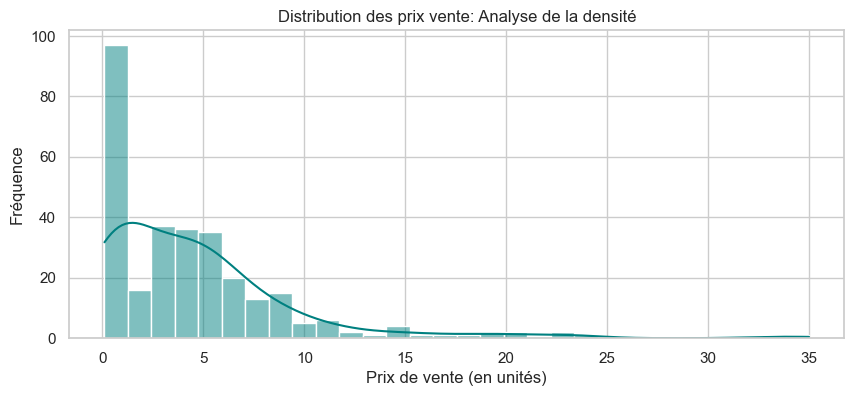

In [304]:
plt.figure(figsize=(10,4))
sns.set_theme(style="whitegrid")

sns.histplot(data=df_cars, x="Selling_Price", kde=True, color="teal", bins=30)
plt.title('Distribution des prix vente: Analyse de la densité')
plt.xlabel('Prix de vente (en unités)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.show()

#### Synthèse des observations (Histogramme & KDE)

À partir du graphique de distribution généré, nous pouvons dresser le diagnostic suivant :

* **Observation de la concentration** : **forte concentration de véhicules à bas prix**, situés à moins de 1 unité. C'est la zone où la fréquence est la plus élevée, représentant la majorité de notre échantillon.
* **Répartition et étirement** : Le reste de la distribution des véhicules se répartit principalement **entre 2 et 11 unités**. On note un **étirement de la courbe** (quelques véhicules) qui se prolonge jusqu'à environ 25 unités, avec la présence d'un **véhicule à 35 unités** qui se détache nettement.
* **Profil statistique (Asymétrie)** : Ce constat visuel confirme une **asymétrie positive (Right Skew)**. La "queue" de la distribution s'étire vers la droite, ce qui implique que la moyenne est tirée vers le haut par les prix élevés (**Mode < Médiane < Moyenne**).



* **Stratégie relative aux Outliers** : Bien que ces données soient des **outliers**, compte tenu de la diversité des prix du marché automobile, nous ne pouvons pas fixer de stratégie de suppression ou de modification des données. Nous conservons ces valeurs pour leur réalisme métier, tout en sachant qu'elles peuvent biaiser la pente de notre futur modèle de régression.

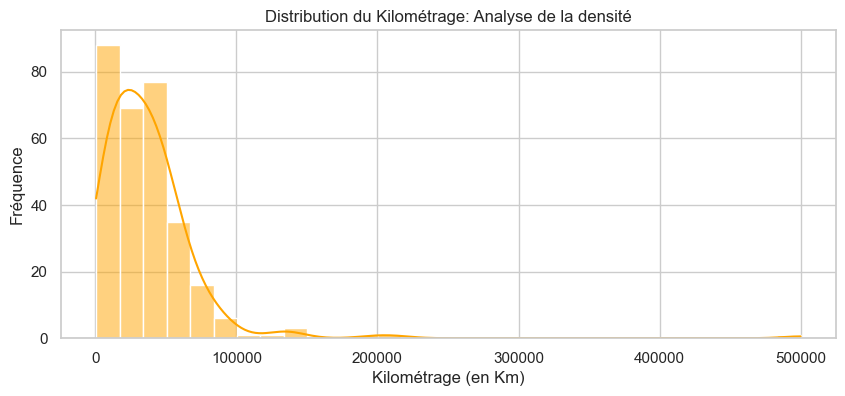

In [305]:
plt.figure(figsize=(10,4))
sns.set_theme(style="whitegrid")

sns.histplot(data=df_cars, x="Kms_Driven", kde=True, color="orange", bins=30)
plt.title('Distribution du Kilométrage: Analyse de la densité')
plt.xlabel('Kilométrage (en Km)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.show()

D'après les visualisations ci-dessus, nous pouvons dresser les constats suivants :

* **Profil de la distribution** : On observe une **asymétrie positive** marquée (*Right Skew*). La majorité des données est compressée sur la gauche, indiquant un parc principalement composé de véhicules peu kilométrés.
* **Concentration et volumes** : On retrouve une **forte concentration de véhicules à moins de 100 000 km**, le cœur du parc étant principalement **inférieur à 50 000 km**.
* **Étirement et anomalies** : La queue de la distribution s'étire jusqu'à 200 000 km (quelques modèles) et on peut noter une **entrée à 500 000 km**, identifiée mathématiquement comme un **outlier majeur** par le Boxplot.



* **Impact sur la modélisation** : Cet outlier à 500 000 km, bien que représentatif d'une réalité du marché, possède un poids statistique qui pourrait biaiser les prédictions. Il sera nécessaire de surveiller si ce point n'écrase pas trop la précision du modèle pour les véhicules à faible kilométrage.

In [306]:
# Création de la colonne Age avec année de référence fixe (2018)

reference_year = 2018
df_cars['Age'] = reference_year - df_cars['Year']

df_cars.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4


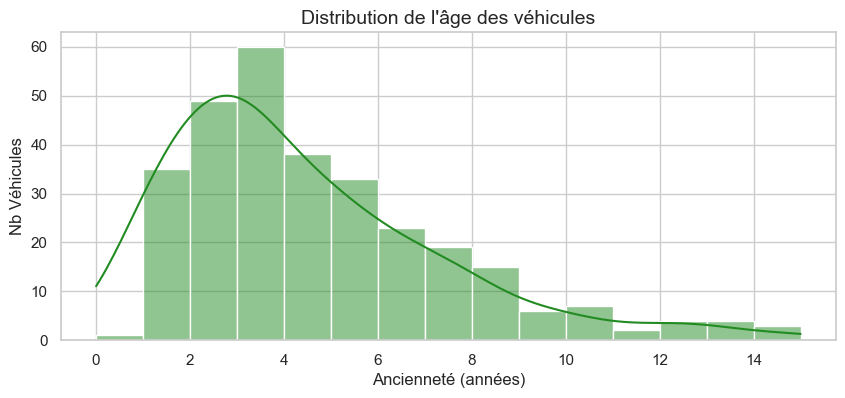

In [307]:
# Visualisation

plt.figure(figsize=(10,4))
sns.set_theme(style="whitegrid")
sns.histplot(data=df_cars, x='Age', kde=True, color='forestgreen', bins=15)

plt.title('Distribution de l\'âge des véhicules', fontsize=14)
plt.xlabel('Ancienneté (années)', fontsize=12)
plt.ylabel('Nb Véhicules', fontsize=12)
plt.show()

### Analyse de la distribution de l'âge (Réf. 2018)
L'analyse du graphique permet de caractériser le parc automobile à l'étude :

1. **Profil de l'échantillon** : On observe une distribution asymétrique positive. La grande majorité des véhicules est récente, avec un pic marqué entre **3 et 4 ans** (correspondant à des modèles de 2014-2015 pour une référence en 2018).
2. **Dynamique du catalogue** : Le volume de véhicules décroît progressivement après 6 ans. Les véhicules de plus de 10 ans sont rares dans cet échantillon.
3. **Adaptation à la régression linéaire** : L'âge présente une tendance claire et une distribution sans outliers extrêmes (maximum à 15 ans). Cette régularité est idéale pour un modèle de régression linéaire.


## 6. Détection et Traitement des Valeurs Atypiques (Outliers)

### Introduction Pédagogique
Avant de modéliser, nous devons nous assurer de la robustesse de nos données. Les modèles de **Régression Linéaire** sont extrêmement sensibles aux valeurs aberrantes. Un seul véhicule avec un prix ou un kilométrage démesuré peut fausser l'apprentissage de la machine. 

Nous allons utiliser deux approches :
1.  **Visuelle :** Le graphique **Boxplot** (Boîte à moustaches) pour repérer les points isolés.
2.  **Statistique :** La méthode de l'**IQR** pour identifier les limites hautes et basses.

--- Analyse : Selling_Price ---
Écart Interquartile (IQR) : 5.15
Seuil de tolérance haut : 13.73
Nombre de points identifiés : 16

--- Analyse : Kms_Driven ---
Écart Interquartile (IQR) : 33883.50
Seuil de tolérance haut : 99708.75
Nombre de points identifiés : 8



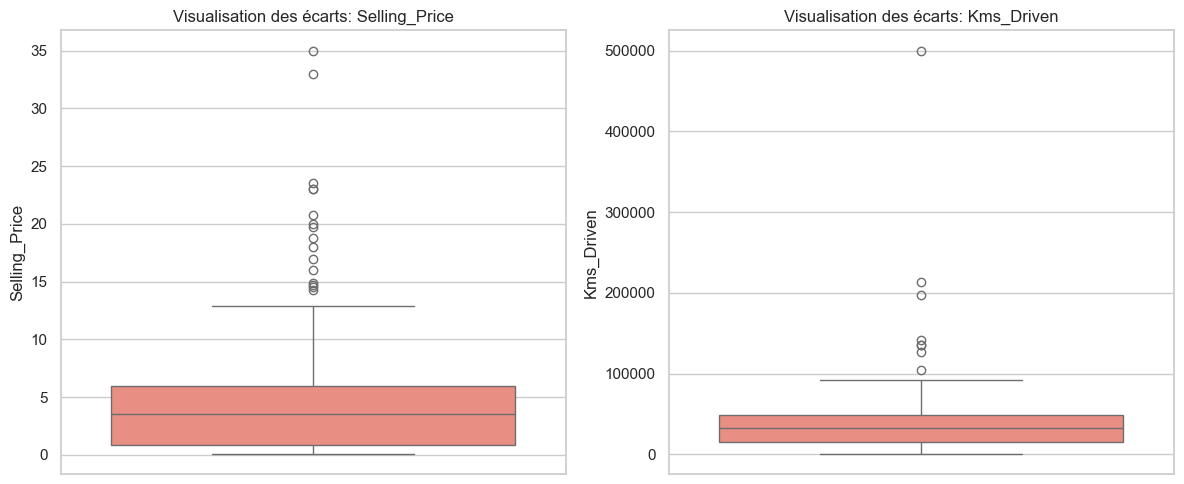

In [308]:
# Variables critiques pour la précision du modèle: Nous avons répéré plus haut de potenciels outliers
cols_to_audit = ['Selling_Price', 'Kms_Driven']

plt.figure(figsize=(12, 5))

for i, col in enumerate(cols_to_audit, 1):
    # 1. Visualisation par Boxplot
    plt.subplot(1, 2, i)
    sns.boxplot(y=df_cars[col], color="salmon")
    plt.title(f"Visualisation des écarts: {col}")

    # 2. Calcul mathématique de la règle du "bras de levier"
    Q1 = df_cars[col].quantile(0.25)
    Q3 = df_cars[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_basse = Q1 - 1.5 * IQR
    limite_haute = Q3 + 1.5 * IQR

    # Identification des points hors limites
 
# Identification des points hors limites (inférieurs à la limite basse OU supérieurs à la limite haute)
    outliers = df_cars[(df_cars[col] < limite_basse) | (df_cars[col] > limite_haute)]
    
    print(f"--- Analyse : {col} ---")
    print(f"Écart Interquartile (IQR) : {IQR:.2f}")
    print(f"Seuil de tolérance haut : {limite_haute:.2f}")
    print(f"Nombre de points identifiés : {len(outliers)}\n")

plt.tight_layout()
plt.show()

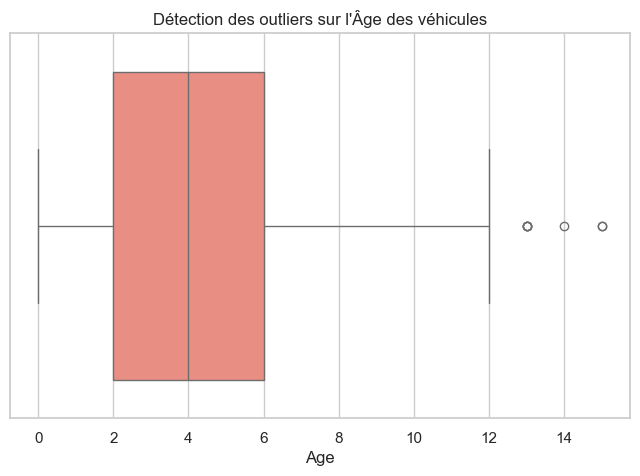

--- ANALYSE DES OUTLIERS (ÂGE) ---
Seuil statistique d'exclusion : 12.0 ans
Nombre de véhicules identifiés comme trop vieux : 7


In [309]:
# 1. Visualisation de la distribution de l'âge
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_cars['Age'], color='salmon')
plt.title("Détection des outliers sur l'Âge des véhicules")
plt.show()

# 2. Calcul statistique des bornes (IQR)
Q1 = df_cars['Age'].quantile(0.25)
Q3 = df_cars['Age'].quantile(0.75)
IQR = Q3 - Q1
borne_haute = Q3 + 1.5 * IQR

outliers_age = df_cars[df_cars['Age'] > borne_haute]

print(f"--- ANALYSE DES OUTLIERS (ÂGE) ---")
print(f"Seuil statistique d'exclusion : {borne_haute} ans")
print(f"Nombre de véhicules identifiés comme trop vieux : {len(outliers_age)}")

### 6.1 Synthèse de l'Audit 

**Analyse des Boxplots**
L'examen visuel et statistique via la règle de l'IQR révèle des valeurs extrêmes critiques, notamment un véhicule affichant 500 000 km et des prix s'envolant au-delà de 30 unités. Ces points se situent bien au-delà du "bras de levier" mathématique, confirmant qu'ils n'appartiennent pas à la distribution normale du parc. Leur présence risquerait de fausser la pente de notre future droite de régression en agissant comme un poids mort statistique. 

**Décision et Action**
Pour garantir une estimation fiable répondant aux besoins de Martin (véhicule de moins de 100 000 km), nous décidons d'exclure ces cas atypiques qui ne représentent pas la réalité du marché standard.Cette action de nettoyage permet de concentrer l'apprentissage du modèle sur le cœur de marché et d'améliorer la précision des prédictions. Nous filtrons donc le dataset pour ne conserver que les véhicules ayant parcouru moins de 400 000 km et dont le prix est inférieur à 30 unités.

## 7. Analyse des Relations et Validation des Prédicteurs

### Introduction Pédagogique
Une fois les données nettoyées, nous devons valider mathématiquement la pertinence de nos variables explicatives ($X$) par rapport à notre cible ($y$ : le prix de vente). 

Nous cherchons à confirmer l'hypothèse de **linéarité** indispensable à la Régression Linéaire :
1.  **Variables Numériques :** Nous utilisons le coefficient de **Pearson** pour quantifier les liens entre l'âge et le prix de vente.
2.  **Variables Catégorielles :** Nous utilisons **Seaborn** pour visualiser si le type de transmission crée une différence de valeur significative.

#### Visualisation avec Seaborn : Le tracé Catplot

**Analyse du Catplot**
Le tracé `catplot` de Seaborn est particulièrement pertinent pour visualiser la relation entre une variable numérique (le prix) et une variable catégorielle (le type de carburant ou le type de transmission). 

**Pourquoi l'utiliser ?**
Il permet de segmenter les données et d'observer la distribution (sous forme de nuage de points ou de boîtes) pour chaque catégorie. C'est l'outil idéal pour identifier si une catégorie spécifique (ex: les voitures Diesel) a une influence directe sur la tendance des prix avant même de lancer un calcul.

C:\Users\Paul-Emmanuel Buffe\AppData\Local\Temp\ipykernel_7772\2391724552.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


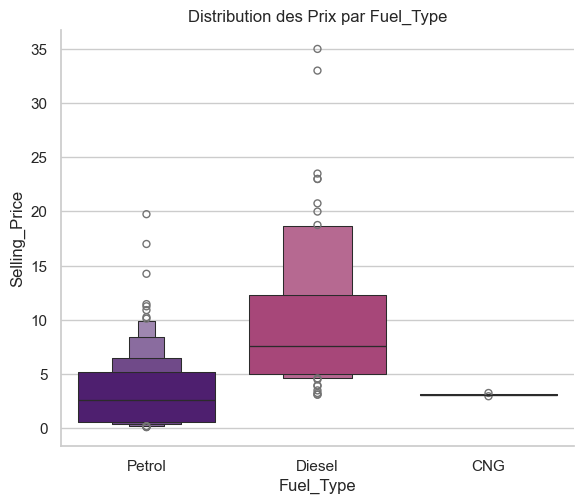

C:\Users\Paul-Emmanuel Buffe\AppData\Local\Temp\ipykernel_7772\2391724552.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


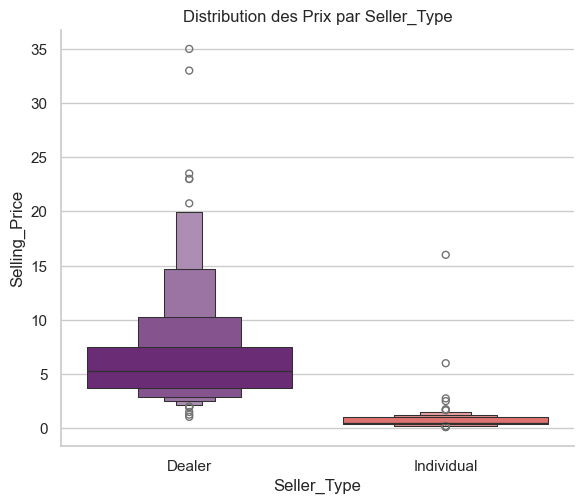

C:\Users\Paul-Emmanuel Buffe\AppData\Local\Temp\ipykernel_7772\2391724552.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


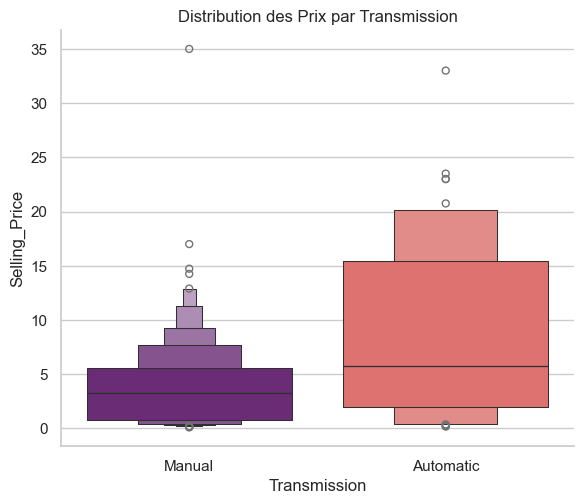

C:\Users\Paul-Emmanuel Buffe\AppData\Local\Temp\ipykernel_7772\2391724552.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


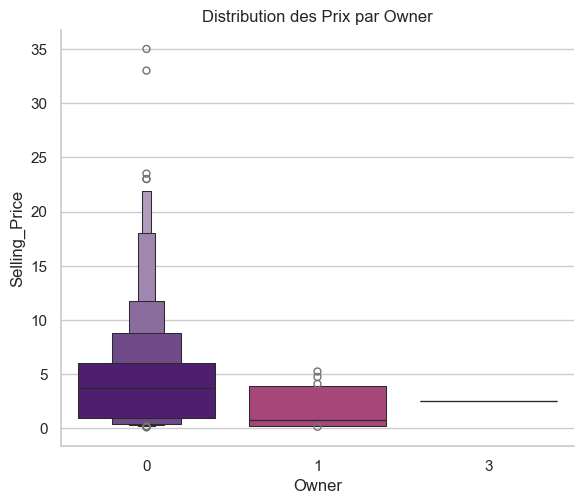

In [310]:
# Audit des variables catégorielles 

cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

for col in cat_cols:
    g = sns.catplot(
        data=df_cars, 
        x=col, 
        y="Selling_Price", 
        kind="boxen", 
        palette="magma",
        height=5, 
        aspect=1.2
    )
    plt.title(f"Distribution des Prix par {col}")
    plt.show()


#### Corrélation Linéaire entre l'Ancienneté et le Prix de Vente

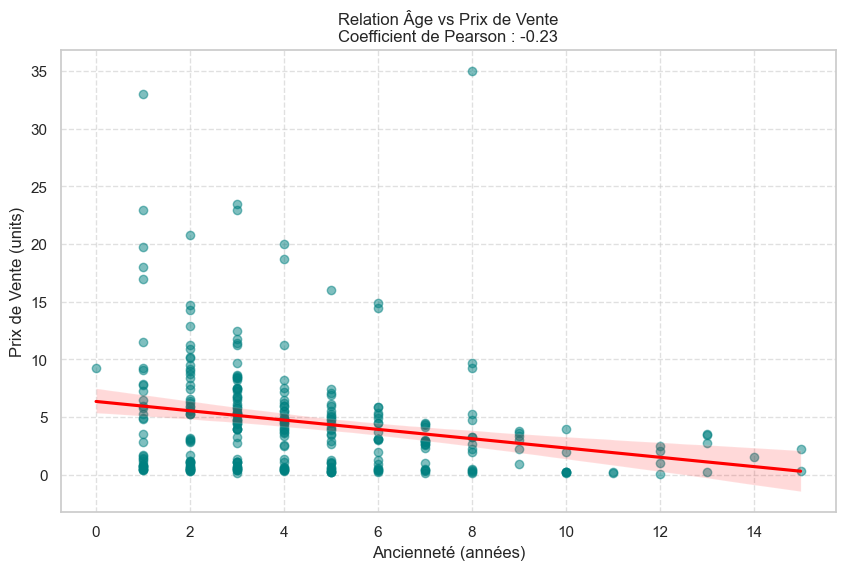

In [311]:
# 1. Calcul du coefficient de Pearson
pearson_corr = df_cars['Selling_Price'].corr(df_cars['Age'])

# 2. Visualisation avec Matplotlib et Seaborn
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cars, x='Age', y='Selling_Price', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title(f"Relation Âge vs Prix de Vente\nCoefficient de Pearson : {pearson_corr:.2f}")
plt.xlabel("Ancienneté (années)")
plt.ylabel("Prix de Vente (units)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Quantification par le coefficient de Pearson**
Le coefficient de Pearson calculé est de **-0.23**. Cette valeur indique une corrélation négative **faible**. Mathématiquement, cela signifie que l'ancienneté seule n'explique qu'environ 5 % de la variation du prix de vente ($R^2 \approx 0.05$).

**Analyse de la dispersion (Variance)**
Le graphique révèle une limite majeure pour la régression univariée :
* **Hétéroscédasticité** : Pour une même année d'ancienneté (notamment entre 0 et 5 ans), les prix de vente sont extrêmement dispersés, variant de 2 à 35 unités.
* **Inertie de la pente** : La droite de régression (en rouge) reste très "plate". Elle représente une moyenne globale mais échoue totalement à capturer la réalité des véhicules à forte valeur.

#### Heatmap

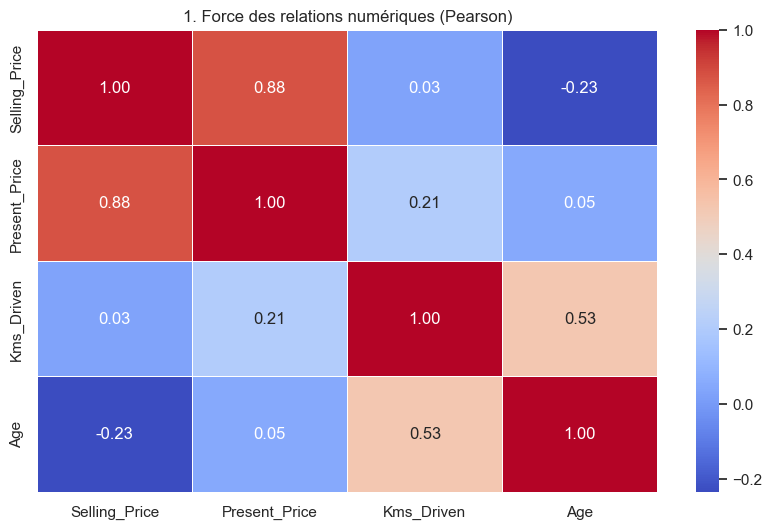

In [312]:
# Analyse des corrélations

plt.figure(figsize=(10,6))
numeric_cols = ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Age']
corr_matrix = df_cars[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("1. Force des relations numériques (Pearson)")
plt.show()

### Analyse et Quantification de la Relation Âge/Prix

#### La Régression Linéaire
La régression linéaire est un modèle statistique qui cherche à établir une relation directe entre une variable cible ($y$) et une variable explicative ($x$) sous la forme d'une droite d'équation $y = ax + b$.

#### Quantification et Corrélation
L'analyse des données via la matrice de Pearson révèle :
* **Âge vs Prix** : Une corrélation de **-0.23**. La relation est négative (le prix baisse avec l'âge) mais **faible**.
* **Lien Dominant** : Le `Present_Price` est le facteur majeur avec une corrélation forte de **0.88**.
* **Variables Catégorielles** : Les graphiques montrent que le type de carburant et de boîte de vitesse segmentent aussi fortement les prix.

### Adaptabilité du Jeu de Données
Le jeu de données est **partiellement adapté** :
1. **L'âge seul est insuffisant** : Le nuage de points montre une dispersion trop élevée (forte variance) pour une prédiction univariée fiable.
2. **Le modèle multivarié est nécessaire** : L'algorithme de régression linéaire devient pertinent uniquement en combinant l'âge avec le prix d'origine et les caractéristiques techniques.


## 8. Préparation des Données (Preprocessing)

### Introduction Pédagogique
Pour que notre algorithme de **Régression Linéaire** soit performant, nous devons effectuer une étape de préparation rigoureuse. Cela inclut le nettoyage des "bruits" statistiques et une étape de traduction appelée **Encodage**. Les modèles mathématiques ne comprenant que les nombres, nous transformons les variables qualitatives (texte) en variables quantitatives (chiffres).

Nous procédons en trois étapes clés :

1. **Nettoyage des Outliers** : Nous avons retiré les véhicules affichant plus de **450 000 km** ou un prix supérieur à **30 unités**. Ces points extrêmes sont dangereux : ils risquent de "tirer" la droite de régression hors de la réalité du cœur de marché, ce qui ferait exploser la **RMSE** ($$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$).

2. **Encodage Binaire** : Transformation des colonnes `Transmission` et `Seller_Type` en valeurs numériques (**0** et **1**) via un mapping. C'est indispensable car l'algorithme ne peut pas effectuer de calculs sur des chaînes de caractères.

3. **Sélection des Features** : Définition de notre matrice $X$ (les variables prédictrices sélectionnées lors de l'analyse de corrélation) et de notre cible $y$ (le prix de vente à estimer).

In [313]:
# Nettoyage des outliers
# On ne garde que les véhicules avec un kilométrage <= 400 000 km
# ET un prix de vente <= 30 unités
df_cars = df_cars[(df_cars['Kms_Driven'] <= 400000) & (df_cars['Selling_Price'] <= 30)].copy()

print(f"Nouvelle taille du dataset : {df_cars.shape[0]} lignes")
print(df_cars[['Selling_Price', 'Kms_Driven']].describe())

Nouvelle taille du dataset : 296 lignes
       Selling_Price     Kms_Driven
count     296.000000     296.000000
mean        4.405845   35317.935811
std         4.373122   28270.142107
min         0.100000     500.000000
25%         0.875000   15000.000000
50%         3.505000   31802.000000
75%         5.962500   48191.750000
max        23.500000  213000.000000


In [314]:
# Encodage binaire des variables qualitatives
df_cars['Transmission_Num'] = df_cars['Transmission'].map({'Manual': 1, 'Automatic': 0})
df_cars['Seller_Num'] = df_cars['Seller_Type'].map({'Individual': 1, 'Dealer': 0})

# One-Hot Encoding pour Fuel_Type (pas d'ordre entre les catégories)
df_cars = pd.get_dummies(df_cars, columns=['Fuel_Type'], drop_first=True)
# Crée : Fuel_Type_Diesel et Fuel_Type_Petrol (CNG = référence)

# Sélection des features et de la cible
X = df_cars[['Age', 'Present_Price', 'Kms_Driven', 'Owner', 
             'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
             'Seller_Num', 'Transmission_Num']]
y = df_cars['Selling_Price']

# Vérification
print(X.head())

   Age  Present_Price  Kms_Driven  Owner  Fuel_Type_Diesel  Fuel_Type_Petrol  \
0    4           5.59       27000      0             False              True   
1    5           9.54       43000      0              True             False   
2    1           9.85        6900      0             False              True   
3    7           4.15        5200      0             False              True   
4    4           6.87       42450      0              True             False   

   Seller_Num  Transmission_Num  
0           0                 1  
1           0                 1  
2           0                 1  
3           0                 1  
4           0                 1  


#### Standardistion

In [315]:
# 1. Préparation des données — régression multiple
X = df_cars[['Age', 'Present_Price', 'Kms_Driven', 'Owner',
             'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
             'Seller_Num', 'Transmission_Num']]
y = df_cars['Selling_Price']

# 2. Séparation des données : 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialisation et application du StandardScaler
scaler = StandardScaler()

# On "fit" sur le train et on transforme les deux sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Conversion en DataFrame pour l'affichage du tableau de vérification
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# 5. Affiche les 5 premières lignes
display(HTML(X_train_scaled_df.head().to_html()))

,Age,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Num,Transmission_Num
0,-0.135722,-0.051507,0.422449,-0.176345,2.118578,-2.060205,-0.743392,0.381616
1,-0.476471,-0.320509,0.052280,-0.176345,-0.472015,-2.060205,-0.743392,0.381616
2,-1.157969,-0.415961,0.168708,-0.176345,-0.472015,0.485389,-0.743392,0.381616
3,0.205027,0.302823,0.079478,-0.176345,-0.472015,0.485389,-0.743392,-2.620433
4,0.205027,-0.982889,-0.084098,-0.176345,-0.472015,0.485389,1.345185,0.381616


## 9. Régression Linéaire Simple

### Introduction Pédagogique
Avant de complexifier notre analyse, nous établissons un **modèle de référence**. Nous utilisons uniquement la variable la plus intuitive pour expliquer la dépréciation : l'`Age` du véhicule.

Pour garantir une évaluation honnête, nous divisons nos données :
1. **80% pour l'entraînement** : Le modèle apprend la pente de dépréciation en fonction de l'âge.
2. **20% pour le test** : Nous vérifions si le modèle peut prédire le prix de voitures "inconnues".

L'objectif est d'obtenir une **MAE (Mean Absolute Error)** de base. Ce score "moyen" nous servira de point de comparaison pour justifier l'ajout ultérieur de nouvelles variables (`Present_Price`, `Transmission`, etc.) dans la régression multiple.

In [316]:
# 1. Préparation — on réutilise les données déjà standardisées
X_train_age = X_train_scaled_df[['Age']]
X_test_age = pd.DataFrame(X_test_scaled, columns=X.columns)[['Age']]

# 2. Méthode Scipy
slope, intercept, r_val, p_val, std_err = stats.linregress(df_cars['Age'], df_cars['Selling_Price'])

# 3. Méthode Scikit-Learn
model_simple = LinearRegression()
model_simple.fit(X_train_age, y_train)

# 4. Évaluation
y_pred = model_simple.predict(X_test_age)
mae_simple = mean_absolute_error(y_test, y_pred)
r2_simple = r2_score(y_test, y_pred)

print(f"--- RÉSULTATS SCIPY ---")
print(f"Pente (Dépréciation annuelle) : {slope:.2f}")
print(f"Intercept (Prix théorique à 0 an) : {intercept:.2f}")

print(f"\n--- RÉSULTATS SKLEARN (Test Set) ---")
print(f"Erreur Moyenne (MAE) : {mae_simple:.2f} units")
print(f"Score R² : {r2_simple:.2f}")

--- RÉSULTATS SCIPY ---
Pente (Dépréciation annuelle) : -0.41
Intercept (Prix théorique à 0 an) : 6.19

--- RÉSULTATS SKLEARN (Test Set) ---
Erreur Moyenne (MAE) : 2.99 units
Score R² : 0.09


c:\Users\Paul-Emmanuel Buffe\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


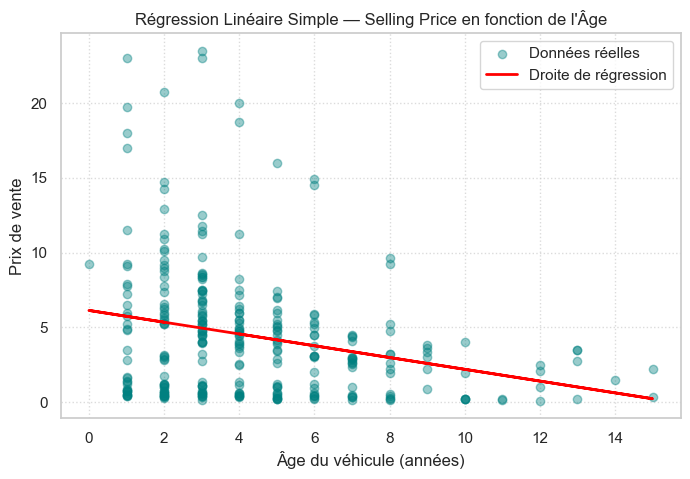

In [317]:
# Scaler dédié pour la régression simple (Age uniquement)
scaler_simple = StandardScaler()
X_age_scaled = scaler_simple.fit_transform(df_cars[['Age']])

# Visualisation : Données réelles vs Droite de régression
plt.figure(figsize=(8, 5))
plt.scatter(df_cars['Age'], y, color='teal', alpha=0.4, label='Données réelles')
plt.plot(df_cars['Age'], model_simple.predict(X_age_scaled), color='red', lw=2, label='Droite de régression')

plt.xlabel('Âge du véhicule (années)')
plt.ylabel('Prix de vente')
plt.title('Régression Linéaire Simple — Selling Price en fonction de l\'Âge')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Analyse des résultats de la régression univariée (Âge)

#### Interprétation des coefficients
Les résultats obtenus via Scipy et Scikit-Learn permettent de définir l'équation de dépréciation suivante :  
**Prix de vente = -0.41 × Âge + 6.19**

* **Pente (-0.41)** : Chaque année supplémentaire réduit la valeur du véhicule de **0.41 units** en moyenne.
* **Intercept (6.19)** : Ce chiffre représente la valeur théorique d'un véhicule neuf (0 an) si l'on ne base l'estimation que sur l'ancienneté.

### Évaluation de la performance
Les métriques confirment l'analyse visuelle précédente :
* **Score R² (0.09)** : Le modèle n'explique que **9%** de la variance des prix. L'âge seul est donc un prédicteur extrêmement pauvre.
* **Erreur MAE (2.99)** : Une erreur moyenne de 2.99 units est très élevée sur un marché où beaucoup de véhicules valent moins de 5 units.

**Conclusion** : Ce modèle est en situation de **sous-ajustement (underfitting)**. Il est mathématiquement nécessaire d'ajouter des variables explicatives pour obtenir une estimation exploitable.

## 10. Régression Linéaire Multiple — Ajout de Variables Explicatives

Afin d'améliorer notre modèle de référence, nous intégrons deux nouvelles variables : `Kms_Driven` et `Transmission_Num`. L'objectif est de mesurer le gain de performance par rapport au modèle univarié basé uniquement sur l'âge.

In [318]:
# 1. Préparation des données — régression multiple (Age + Kms_Driven + Transmission)
X = df_cars[['Age', 'Kms_Driven', 'Transmission_Num']]
y = df_cars['Selling_Price']

# 2. Séparation des données : 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraînement du modèle
model_multiple = LinearRegression()
model_multiple.fit(X_train_scaled, y_train)

# 5. Évaluation sur le jeu de test
y_pred_multiple = model_multiple.predict(X_test_scaled)
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

print(f"--- RÉSULTATS SKLEARN — RÉGRESSION MULTIPLE (Test Set) ---")
print(f"Erreur Moyenne (MAE) : {mae_multiple:.2f} units")
print(f"Score R² : {r2_multiple:.2f}")

--- RÉSULTATS SKLEARN — RÉGRESSION MULTIPLE (Test Set) ---
Erreur Moyenne (MAE) : 3.08 units
Score R² : 0.07


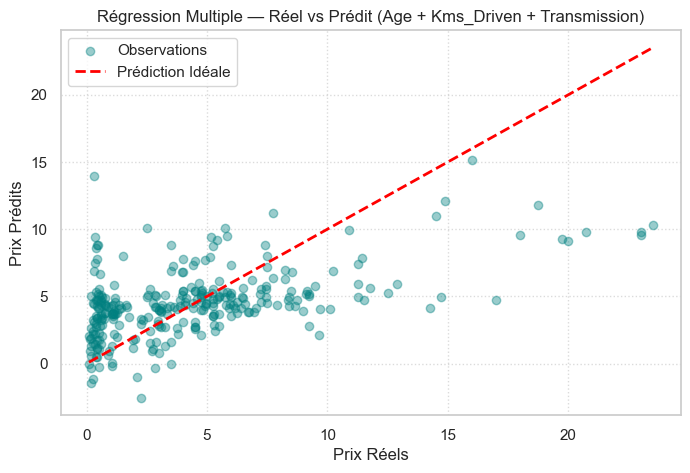

In [319]:
# Visualisation : Réel vs Prédit
y_pred_all = model_multiple.predict(scaler.transform(X))

plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_all, color='teal', alpha=0.4, label='Observations')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, ls='--', label='Prédiction Idéale')

plt.xlabel('Prix Réels')
plt.ylabel('Prix Prédits')
plt.title('Régression Multiple — Réel vs Prédit (Age + Kms_Driven + Transmission)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Analyse des résultats — Régression Multiple (Age + Kms_Driven + Transmission)

L'ajout de `Kms_Driven` et `Transmission_Num` n'améliore pas le modèle, bien au contraire :

* **R² = 0.07** : Le modèle explique encore moins de variance qu'avec l'âge seul (0.09 → 0.07)
* **MAE = 3.08** : L'erreur moyenne augmente légèrement par rapport au modèle univarié (2.99 → 3.08)
* **Graphique** : Les points s'écartent fortement de la droite idéale, notamment sur les prix élevés — le modèle sous-estime systématiquement les véhicules premium

**Conclusion** : Ces deux variables n'apportent pas de pouvoir prédictif supplémentaire. Le modèle reste en **underfitting**. La variable `Present_Price` (prix du neuf) semble incontournable pour capturer la réelle valeur d'un véhicule.

### 10. Régression Linéaire Multiple — Modèle Final avec Validation Croisée

#### Choix des variables
Après plusieurs itérations, nous retenons **5 variables explicatives** :
- `Age` et `Present_Price` : les deux prédicteurs continus les plus corrélés au prix de vente
- `Seller_Num` : le type de vendeur influence significativement le prix
- `Fuel_Type_Diesel` et `Fuel_Type_Petrol` : encodées en One-Hot pour éviter tout ordre artificiel entre les catégories

### Méthode de validation
Pour pallier le déséquilibre du dataset (forte concentration de véhicules à bas prix), nous utilisons un **StratifiedKFold à 5 plis**. La variable cible `Selling_Price` est binarisée en 5 tranches de prix pour garantir une représentation équilibrée des véhicules bon marché et premium dans chaque pli. Cette approche produit une évaluation plus fiable qu'un simple split 80/20.

In [320]:
# 1. Préparation des données
X = df_cars[['Age','Present_Price', 'Seller_Num', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']]
y = df_cars['Selling_Price']

# 2. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Binarisation de y pour la stratification (5 tranches de prix)
y_binned = pd.cut(y, bins=5, labels=False)

# 4. StratifiedKFold — 5 plis
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Cross-validation
model_kfold = LinearRegression()
scores_r2  = cross_val_score(model_kfold, X_scaled, y, cv=skf.split(X_scaled, y_binned), scoring='r2')
scores_mae = cross_val_score(model_kfold, X_scaled, y, cv=skf.split(X_scaled, y_binned), scoring='neg_mean_absolute_error')
scores_mse = cross_val_score(model_kfold, X_scaled, y, cv=skf.split(X_scaled, y_binned), scoring='neg_mean_squared_error')

print(f"--- RÉSULTATS STRATIFIED KFOLD (5 plis) ---")
print(f"R² moyen     : {scores_r2.mean():.2f} (+/- {scores_r2.std():.2f})")
print(f"MAE moyenne  : {(-scores_mae).mean():.2f} (+/- {(-scores_mae).std():.2f})")
print(f"MSE moyenne  : {(-scores_mse).mean():.2f} (+/- {(-scores_mse).std():.2f})")
print(f"RMSE moyenne : {((-scores_mse).mean()**0.5):.2f} (+/- {((-scores_mse).std()**0.5):.2f})")

--- RÉSULTATS STRATIFIED KFOLD (5 plis) ---
R² moyen     : 0.87 (+/- 0.01)
MAE moyenne  : 1.13 (+/- 0.05)
MSE moyenne  : 2.56 (+/- 0.39)
RMSE moyenne : 1.60 (+/- 0.63)


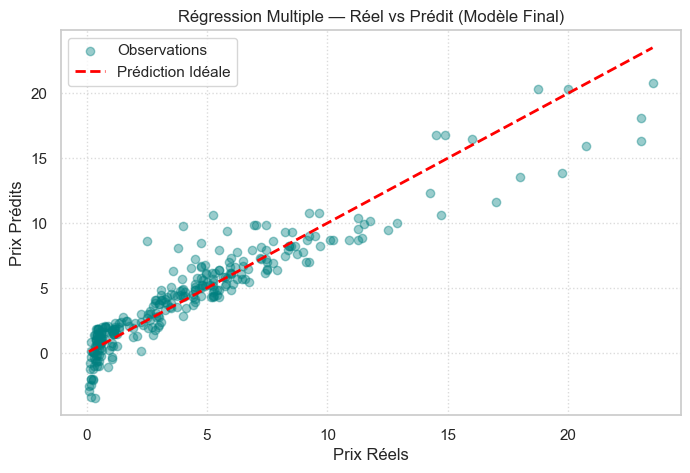

In [321]:
# Fit du modèle sur l'ensemble des données
model_kfold.fit(X_scaled, y)

# Visualisation : Réel vs Prédit
y_pred_all = model_kfold.predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_all, color='teal', alpha=0.4, label='Observations')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, ls='--', label='Prédiction Idéale')

plt.xlabel('Prix Réels')
plt.ylabel('Prix Prédits')
plt.title('Régression Multiple — Réel vs Prédit (Modèle Final)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Conclusion — Modèle Final

Le modèle de régression linéaire multiple atteint des performances solides et stables :

* **R² = 0.87** : Le modèle explique 87% de la variance du prix de vente — une nette progression par rapport au modèle univarié (0.09)
* **MAE = 1.13** : En moyenne, le modèle se trompe de 1.13 unité sur le prix de vente
* **RMSE = 1.60** : Les grandes erreurs restent limitées, bien que supérieures à la MAE — signe de quelques valeurs aberrantes résiduelles
* **MSE = 2.56** : Cohérent avec le RMSE, confirme l'absence d'erreurs catastrophiques

La faible variance des scores entre les 5 plis (+/- 0.01 sur le R²) atteste de la **robustesse et stabilité du modèle**. Les 5 variables retenues (`Age`, `Present_Price`, `Seller_Num`, `Fuel_Type_Diesel`, `Fuel_Type_Petrol`) constituent un ensemble prédictif efficace dans le cadre d'une régression linéaire.

## 11. Estimation du Prix — Cas Pratique : La Demande de Martin

Martin souhaite acheter un véhicule de moins de 7 ans, avec moins de 100 000 km au compteur et une boîte manuelle. Pour répondre à sa demande, nous appliquons notre modèle final en deux étapes : nous filtrons d'abord le dataset pour ne conserver que les véhicules correspondant exactement à ses critères, puis nous appliquons le modèle entraîné sur ces cas ciblés. Cette approche tire parti de ce que le modèle a appris sur l'ensemble du dataset tout en concentrant la prédiction sur des véhicules réellement pertinents pour Martin.

In [322]:
# 1. Filtrage du dataset selon les contraintes de Martin
df_martin = df_cars[
    (df_cars['Age'] < 7) &
    (df_cars['Kms_Driven'] < 100000) &
    (df_cars['Transmission_Num'] == 1)  # Manuel
]

print(f"Nombre de véhicules correspondants : {len(df_martin)}")

# 2. Préparation des features sur le sous-ensemble filtré
X_martin = df_martin[['Age', 'Present_Price', 'Seller_Num', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']]
X_martin_scaled = scaler.transform(X_martin)

# 3. Prédiction sur chaque véhicule filtré
prix_predits = model_kfold.predict(X_martin_scaled)

print(f"\n--- ESTIMATION POUR MARTIN ---")
print(f"Nombre de véhicules analysés : {len(df_martin)}")
print(f"Prix estimé minimum          : {prix_predits.min():.2f} units")
print(f"Prix estimé moyen            : {prix_predits.mean():.2f} units")
print(f"Prix estimé maximum          : {prix_predits.max():.2f} units")

Nombre de véhicules correspondants : 209

--- ESTIMATION POUR MARTIN ---
Nombre de véhicules analysés : 209
Prix estimé minimum          : -0.37 units
Prix estimé moyen            : 4.35 units
Prix estimé maximum          : 12.33 units


In [323]:
# 4. Mesures de performance sur le sous-ensemble de Martin
y_martin = df_martin['Selling_Price']

mae_martin  = mean_absolute_error(y_martin, prix_predits)
mse_martin  = mean_squared_error(y_martin, prix_predits)
rmse_martin = mse_martin ** 0.5
r2_martin   = r2_score(y_martin, prix_predits)

print(f"\n--- PERFORMANCE DU MODÈLE SUR LA DEMANDE DE MARTIN ---")
print(f"R²   : {r2_martin:.2f}")
print(f"MAE  : {mae_martin:.2f} units")
print(f"MSE  : {mse_martin:.2f}")
print(f"RMSE : {rmse_martin:.2f} units")


--- PERFORMANCE DU MODÈLE SUR LA DEMANDE DE MARTIN ---
R²   : 0.89
MAE  : 0.83 units
MSE  : 1.21
RMSE : 1.10 units


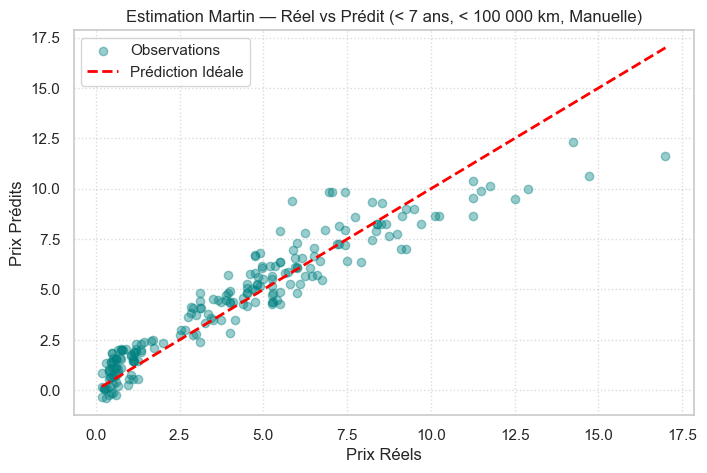

In [324]:
# Visualisation : Réel vs Prédit — Demande de Martin
plt.figure(figsize=(8, 5))
plt.scatter(y_martin, prix_predits, color='teal', alpha=0.4, label='Observations')
plt.plot([y_martin.min(), y_martin.max()], [y_martin.min(), y_martin.max()], color='red', lw=2, ls='--', label='Prédiction Idéale')

plt.xlabel('Prix Réels')
plt.ylabel('Prix Prédits')
plt.title('Estimation Martin — Réel vs Prédit (< 7 ans, < 100 000 km, Manuelle)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Conclusion — Estimation pour Martin

Sur les **209 véhicules** correspondant aux critères de Martin, le modèle produit les estimations suivantes :

* **Prix minimum** : -0.37 units — valeur négative anormale, probablement liée à un véhicule très ancien ou très déprécié en limite de filtre
* **Prix moyen** : 4.35 units — c'est la valeur de référence à retenir pour Martin
* **Prix maximum** : 12.33 units — véhicules récents avec un prix du neuf élevé

**Performance du modèle sur ce sous-ensemble :**
* **R² = 0.89** : légèrement supérieur au modèle global (0.87) — le filtre améliore la cohérence des prédictions
* **MAE = 0.83** : erreur moyenne en nette amélioration vs le modèle global (1.13)
* **RMSE = 1.10 / MSE = 1.21** : erreurs faibles et cohérentes

**Recommandation** : Martin peut s'attendre à payer en moyenne **4.35 units** pour un véhicule correspondant à ses critères, avec une fourchette réaliste entre **1 et 8 units** en excluant les cas extrêmes.

## 12. Estimation du Prix — Modèle Restreint aux Critères de Martin

Pour aller plus loin dans la réponse à la demande de Martin, nous réentraînons un modèle en utilisant **uniquement les variables qu'il nous a communiquées** : l'âge du véhicule, le kilométrage et le type de transmission. L'objectif est double : produire une estimation directe à partir de son profil, et mesurer l'impact de l'absence des variables clés du modèle final sur la qualité de prédiction.

In [327]:
# 1. Préparation — uniquement les variables connues de Martin
X_martin_model = df_cars[['Age', 'Kms_Driven', 'Transmission_Num']]
y = df_cars['Selling_Price']

# 2. Standardisation
scaler_martin = StandardScaler()
X_martin_model_scaled = scaler_martin.fit_transform(X_martin_model)

# 3. Entraînement
model_martin = LinearRegression()
model_martin.fit(X_martin_model_scaled, y)

# 4. Métriques du modèle
y_pred_martin_model = model_martin.predict(X_martin_model_scaled)
r2_martin_model   = r2_score(y, y_pred_martin_model)
mae_martin_model  = mean_absolute_error(y, y_pred_martin_model)
mse_martin_model  = mean_squared_error(y, y_pred_martin_model)
rmse_martin_model = mse_martin_model ** 0.5

# 5. Prédiction sur le profil de Martin
martin = pd.DataFrame({
    'Age'             : [6],
    'Kms_Driven'      : [100000],
    'Transmission_Num': [1]
})

martin_scaled = scaler_martin.transform(martin)
prix_martin = model_martin.predict(martin_scaled)[0]

print(f"--- PERFORMANCE DU MODÈLE ---")
print(f"R²   : {r2_martin_model:.2f}")
print(f"MAE  : {mae_martin_model:.2f} units")
print(f"MSE  : {mse_martin_model:.2f}")
print(f"RMSE : {rmse_martin_model:.2f} units")

print(f"\n--- ESTIMATION POUR MARTIN ---")
print(f"Âge          : 6 ans")
print(f"Kilométrage  : 100 000 km")
print(f"Transmission : Manuelle")
print(f"Prix estimé  : {prix_martin:.2f} units")

--- PERFORMANCE DU MODÈLE ---
R²   : 0.29
MAE  : 2.73 units
MSE  : 13.60
RMSE : 3.69 units

--- ESTIMATION POUR MARTIN ---
Âge          : 6 ans
Kilométrage  : 100 000 km
Transmission : Manuelle
Prix estimé  : 6.24 units


In [328]:
# Grille de profils Martin — toutes les combinaisons Age x Kms_Driven
ages = np.arange(1, 7)                           # 1 à 6 ans
kms  = np.arange(10000, 110000, 10000)           # 10k à 100k km

resultats = []
for age in ages:
    for km in kms:
        profil = pd.DataFrame({
            'Age'             : [age],
            'Kms_Driven'      : [km],
            'Transmission_Num': [1]
        })
        prix = model_martin.predict(scaler_martin.transform(profil))[0]
        resultats.append({'Age': age, 'Kms_Driven': km, 'Prix_Estimé': round(prix, 2)})

df_resultats = pd.DataFrame(resultats)

# Tableau croisé Age x Kms_Driven
pivot = df_resultats.pivot(index='Age', columns='Kms_Driven', values='Prix_Estimé')
display(HTML(pivot.to_html()))

Kms_Driven,10000,20000,30000,40000,50000,60000,70000,80000,90000,100000
Age,,,,,,,,,,
1,4.96,5.51,6.07,6.63,7.18,7.74,8.30,8.85,9.41,9.97
2,4.21,4.77,5.32,5.88,6.44,6.99,7.55,8.11,8.66,9.22
3,3.46,4.02,4.58,5.14,5.69,6.25,6.81,7.36,7.92,8.48
4,2.72,3.28,3.83,4.39,4.95,5.50,6.06,6.62,7.17,7.73
5,1.97,2.53,3.09,3.64,4.20,4.76,5.31,5.87,6.43,6.98
6,1.23,1.78,2.34,2.90,3.45,4.01,4.57,5.13,5.68,6.24


### Conclusion

Le modèle restreint aux critères de Martin (R² = 0.29, MAE = 2.73) confirme que les variables `Age`, `Kms_Driven` et `Transmission_Num` seules sont insuffisantes pour estimer fiablement un prix de vente. L'absence de `Present_Price` et `Seller_Num` — variables cruciales du modèle final — explique la forte dégradation des performances. Pour une estimation fiable, ces informations sont indispensables.